y = sigmoid(W * a[i] + b)

#### Single input, Multiple wights

Epoch 0: Loss=0.354121, y_pred=0.595080
Epoch 50: Loss=0.042954, y_pred=0.207253
Epoch 100: Loss=0.017821, y_pred=0.133495
Epoch 150: Loss=0.010704, y_pred=0.103458
Epoch 200: Loss=0.007506, y_pred=0.086635
Epoch 250: Loss=0.005724, y_pred=0.075654
Epoch 300: Loss=0.004599, y_pred=0.067816
Epoch 350: Loss=0.003829, y_pred=0.061883
Epoch 400: Loss=0.003272, y_pred=0.057201
Epoch 450: Loss=0.002851, y_pred=0.053393

Final y_pred: 0.05027741514032015 (target 0.0)


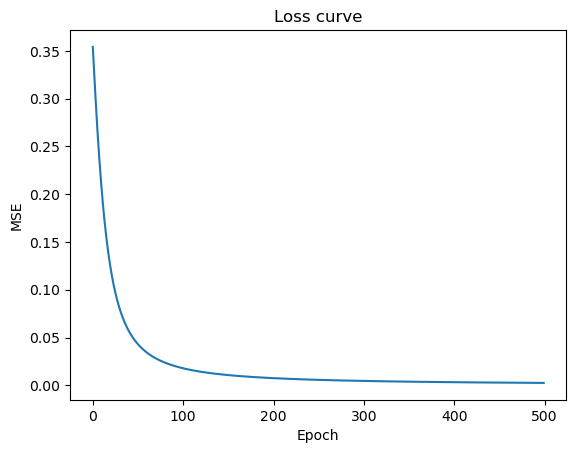

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigp(a): 
    return a * (1 - a)

# data
X = np.array([[1.0]])      # shape (1,1)
y_true = np.array([[0.0]]) # shape (1,1)

# weights
W1 = np.array([[0.5, 0.6, 0.7]], dtype=float)   # (1,3)
b1 = np.zeros((1,3), dtype=float)               # (1,3)

W2 = np.array([[0.2],
               [0.3],
               [0.1]], dtype=float)             # (3,1)
b2 = np.zeros((1,1), dtype=float)               # (1,1)

lr = 0.1
history_loss = []

for epoch in range(500):
    # ---- forward ----
    z1 = X @ W1 + b1          # (1,3)
    h  = sigmoid(z1)          # (1,3)

    z2 = h @ W2 + b2          # (1,1)
    y_pred = sigmoid(z2)      # (1,1)

    loss = np.mean((y_pred - y_true) ** 2)
    history_loss.append(loss)

    # ---- backward ----
    dL_dy = 2 * (y_pred - y_true)     # (1,1)
    dL_dz2 = dL_dy * sigp(y_pred)     # (1,1)

    dL_dW2 = h.T @ dL_dz2             # (3,1)
    dL_db2 = dL_dz2                   # (1,1)

    dL_dh  = dL_dz2 @ W2.T            # (1,3)
    dL_dz1 = dL_dh * sigp(h)          # (1,3)

    dL_dW1 = X.T @ dL_dz1             # (1,3)
    dL_db1 = dL_dz1                   # (1,3)

    # ---- update ----
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss={loss:.6f}, y_pred={y_pred.item():.6f}")

print("\nFinal y_pred:", y_pred.item(), "(target 0.0)")

plt.plot(history_loss)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

##### XOR Prediction

In [114]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigp(a): 
    return a * (1 - a)

#data 
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

#1. Initialization (2 inputs, 4 hidden, 1 output)
#np.random.seed(42)
W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))
W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))
lr = 1

#2. Training loop
for epoch in range(1000):
    #Forward pass
    z1 = np.dot(X,W1) + b1
    h = sigmoid(z1)
    z2 = np.dot(h,W2) + b2
    y_pred = sigmoid(z2)

    loss = np.mean((y_pred - y) ** 2)

    # Backpropagation
    error = y - y_pred
    d_final = error * sigp(y_pred)
    
    error_hidden = d_final.dot(W2.T)
    d_hidden = error_hidden * sigp(h)

    # Update weights and biases

    W2 += h.T.dot(d_final) * lr
    b2 += np.sum(d_final, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss={loss:.6f}")

    


Epoch 0: Loss=0.360415
Epoch 50: Loss=0.245713
Epoch 100: Loss=0.232427
Epoch 150: Loss=0.202836
Epoch 200: Loss=0.163974
Epoch 250: Loss=0.111544
Epoch 300: Loss=0.060017
Epoch 350: Loss=0.032259
Epoch 400: Loss=0.019693
Epoch 450: Loss=0.013438
Epoch 500: Loss=0.009917
Epoch 550: Loss=0.007731
Epoch 600: Loss=0.006270
Epoch 650: Loss=0.005237
Epoch 700: Loss=0.004474
Epoch 750: Loss=0.003891
Epoch 800: Loss=0.003434
Epoch 850: Loss=0.003067
Epoch 900: Loss=0.002766
Epoch 950: Loss=0.002515


Epoch 0: Loss=0.283190, Accuracy=0.500000
Epoch 1000: Loss=0.183325, Accuracy=0.750000
Epoch 2000: Loss=0.020997, Accuracy=1.000000
Epoch 3000: Loss=0.005533, Accuracy=1.000000
Epoch 4000: Loss=0.002786, Accuracy=1.000000


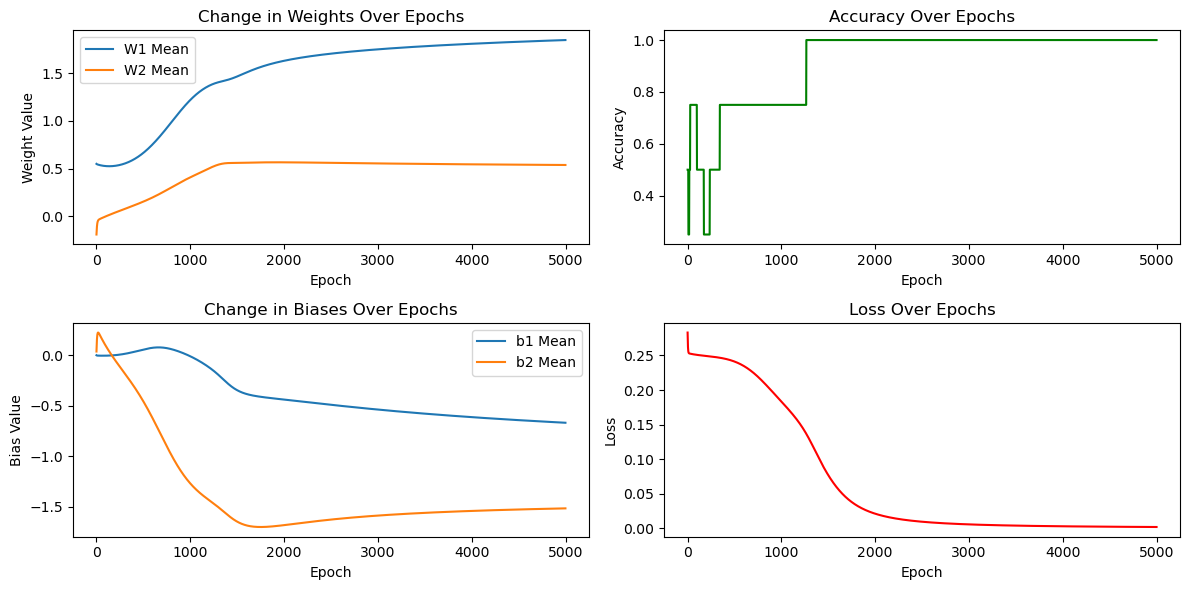

In [126]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigp(a): 
    return a * (1 - a)

# Data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Initialization (2 inputs, 4 hidden, 1 output)
np.random.seed(42)
W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))
W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))
lr = 0.5

# History for visualization
history_loss = []
history_accuracy = []
history_W1 = []
history_W2 = []
history_b1 = []
history_b2 = []

# Training loop
for epoch in range(5000):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    h = sigmoid(z1)
    z2 = np.dot(h, W2) + b2
    y_pred = sigmoid(z2)

    loss = np.mean((y_pred - y) ** 2)
    
    # Accuracy Calculation
    accuracy = np.mean((y_pred > 0.5) == y)
    
    # Backpropagation
    error = 2 * (y_pred - y) / 4
    d_final = error * sigp(y_pred)
    
    error_hidden = d_final.dot(W2.T)
    d_hidden = error_hidden * sigp(h)

    # Update weights and biases
    W2 -= h.T.dot(d_final) * lr
    b2 -= np.sum(d_final, axis=0, keepdims=True) * lr
    W1 -= X.T.dot(d_hidden) * lr
    b1 -= np.sum(d_hidden, axis=0, keepdims=True) * lr

    # Store values for visualization
    history_loss.append(loss)
    history_accuracy.append(accuracy)
    history_W1.append(W1.copy())  # Store the weight change
    history_W2.append(W2.copy())  # Store the weight change
    history_b1.append(b1.copy())  # Store the bias change
    history_b2.append(b2.copy())  # Store the bias change
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss={loss:.6f}, Accuracy={accuracy:.6f}")

# Visualization of changes

# Plot weight changes over epochs
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot([np.mean(W1) for W1 in history_W1], label='W1 Mean')
plt.plot([np.mean(W2) for W2 in history_W2], label='W2 Mean')
plt.title('Change in Weights Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend()

# Plot accuracy over epochs
plt.subplot(2, 2, 2)
plt.plot(history_accuracy, color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot bias changes over epochs
plt.subplot(2, 2, 3)
plt.plot([np.mean(b1) for b1 in history_b1], label='b1 Mean')
plt.plot([np.mean(b2) for b2 in history_b2], label='b2 Mean')
plt.title('Change in Biases Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.legend()

# Plot loss over epochs
plt.subplot(2, 2, 4)
plt.plot(history_loss, color='red')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()